# DSMarket - First look at input files

## 1. Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import OrdinalEncoder

from prophet import Prophet
import xgboost as xgb
import lightgbm as lgb

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

import warnings
warnings.filterwarnings("ignore")

pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

c:\Users\jonmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## 2. Paths and directories

In [2]:
sales_data_path = r"data\item_sales.csv"
calendar_data_path = r"data\daily_calendar_with_events.csv"
prices_data_path = r"data\item_prices.csv"

## 3. Import files

### 3A. Sales data

In [3]:
pd_sales = pd.read_csv(sales_data_path, sep = ",")
print("The shape of the sales datataframe is :", pd_sales.shape)

The shape of the sales datataframe is : (30490, 1920)


In [4]:
pd_sales.head()

,id,item,category,department,store,store_code,region,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100,d_101,d_102,d_103,d_104,d_105,d_106,d_107,d_108,d_109,d_110,d_111,d_112,d_113,d_114,d_115,d_116,d_117,d_118,d_119,d_120,d_121,d_122,d_123,d_124,d_125,d_126,d_127,d_128,d_129,d_130,d_131,d_132,d_133,d_134,d_135,d_136,d_137,d_138,d_139,d_140,d_141,d_142,d_143,d_144,d_145,d_146,d_147,d_148,d_149,d_150,d_151,d_152,d_153,d_154,d_155,d_156,d_157,d_158,d_159,d_160,d_161,d_162,d_163,d_164,d_165,d_166,d_167,d_168,d_169,d_170,d_171,d_172,d_173,d_174,d_175,d_176,d_177,d_178,d_179,d_180,d_181,d_182,d_183,d_184,d_185,d_186,d_187,d_188,d_189,d_190,d_191,d_192,d_193,d_194,d_195,d_196,d_197,d_198,d_199,d_200,d_201,d_202,d_203,d_204,d_205,d_206,d_207,d_208,d_209,d_210,d_211,d_212,d_213,d_214,d_215,d_216,d_217,d_218,d_219,d_220,d_221,d_222,d_223,d_224,d_225,d_226,d_227,d_228,d_229,d_230,d_231,d_232,d_233,d_234,d_235,d_236,d_237,d_238,d_239,d_240,d_241,d_242,d_243,...,d_1664,d_1665,d_1666,d_1667,d_1668,d_1669,d_1670,d_1671,d_1672,d_1673,d_1674,d_1675,d_1676,d_1677,d_1678,d_1679,d_1680,d_1681,d_1682,d_1683,d_1684,d_1685,d_1686,d_1687,d_1688,d_1689,d_1690,d_1691,d_1692,d_1693,d_1694,d_1695,d_1696,d_1697,d_1698,d_1699,d_1700,d_1701,d_1702,d_1703,d_1704,d_1705,d_1706,d_1707,d_1708,d_1709,d_1710,d_1711,d_1712,d_1713,d_1714,d_1715,d_1716,d_1717,d_1718,d_1719,d_1720,d_1721,d_1722,d_1723,d_1724,d_1725,d_1726,d_1727,d_1728,d_1729,d_1730,d_1731,d_1732,d_1733,d_1734,d_1735,d_1736,d_1737,d_1738,d_1739,d_1740,d_1741,d_1742,d_1743,d_1744,d_1745,d_1746,d_1747,d_1748,d_1749,d_1750,d_1751,d_1752,d_1753,d_1754,d_1755,d_1756,d_1757,d_1758,d_1759,d_1760,d_1761,d_1762,d_1763,d_1764,d_1765,d_1766,d_1767,d_1768,d_1769,d_1770,d_1771,d_1772,d_1773,d_1774,d_1775,d_1776,d_1777,d_1778,d_1779,d_1780,d_1781,d_1782,d_1783,d_1784,d_1785,d_1786,d_1787,d_1788,d_1789,d_1790,d_1791,d_1792,d_1793,d_1794,d_1795,d_1796,d_1797,d_1798,d_1799,d_1800,d_1801,d_1802,d_1803,d_1804,d_1805,d_1806,d_1807,d_1808,d_1809,d_1810,d_1811,d_1812,d_1813,d_1814,d_1815,d_1816,d_1817,d_1818,d_1819,d_1820,d_1821,d_1822,d_1823,d_1824,d_1825,d_1826,d_1827,d_1828,d_1829,d_1830,d_1831,d_1832,d_1833,d_1834,d_1835,d_1836,d_1837,d_1838,d_1839,d_1840,d_1841,d_1842,d_1843,d_1844,d_1845,d_1846,d_1847,d_1848,d_1849,d_1850,d_1851,d_1852,d_1853,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,2,0,2,2,0,0,0,1,1,0,2,0,1,1,2,0,1,0,0,0,2,1,0,1,1,2,0,0,0,0,0,0,0,1,0,1,0,1,0,3,1,1,0,1,1,2,0,0,0,0,1,1,0,0,0,0,3,0,1,0,0,0,0,1,1,1,0,1,0,2,0,0,0,0,2,0,0,0,0,1,1,2,0,0,0,0,2,0,0,1,1,1,1,0,0,0,0,0,1,2,2,0,1,0,0,0,0,1,2,1,0,0,0,0,0,1,0,3,0,1,2,1,0,3,

In [5]:
pd_sales.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Data columns (total 1920 columns):
 #     Column      Dtype 
---    ------      ----- 
 0     id          object
 1     item        object
 2     category    object
 3     department  object
 4     store       object
 5     store_code  object
 6     region      object
 7     d_1         int64 
 8     d_2         int64 
 9     d_3         int64 
 10    d_4         int64 
 11    d_5         int64 
 12    d_6         int64 
 13    d_7         int64 
 14    d_8         int64 
 15    d_9         int64 
 16    d_10        int64 
 17    d_11        int64 
 18    d_12        int64 
 19    d_13        int64 
 20    d_14        int64 
 21    d_15        int64 
 22    d_16        int64 
 23    d_17        int64 
 24    d_18        int64 
 25    d_19        int64 
 26    d_20        int64 
 27    d_21        int64 
 28    d_22        int64 
 29    d_23        int64 
 30    d_24        int64 
 31    d_25        int64 
 32  

How many **stores** are there in the data?

In [6]:
print("There are {} stores in the data, and the number of registers per store are: ".format(pd_sales.store.nunique()))
pd_sales.store.value_counts()

There are 10 stores in the data, and the number of registers per store are: 


store
Greenwich_Village    3049
Harlem               3049
Tribeca              3049
Brooklyn             3049
South_End            3049
Roxbury              3049
Back_Bay             3049
Midtown_Village      3049
Yorktown             3049
Queen_Village        3049
Name: count, dtype: int64

How many **items**?

In [7]:
print("There are {} items in the data, and the number of registers per item are: ".format(pd_sales.item.nunique()))
pd_sales.item.value_counts()

There are 3049 items in the data, and the number of registers per item are: 


item
SUPERMARKET_3_827    10
ACCESORIES_1_001     10
ACCESORIES_1_002     10
ACCESORIES_1_003     10
ACCESORIES_1_004     10
                     ..
ACCESORIES_1_013     10
ACCESORIES_1_014     10
ACCESORIES_1_015     10
ACCESORIES_1_016     10
ACCESORIES_1_017     10
Name: count, Length: 3049, dtype: int64

And **departments**?

In [8]:
print("There are {} departments in the data, and the number of registers per department are: ".format(pd_sales.department.nunique()))
pd_sales.department.value_counts()

There are 7 departments in the data, and the number of registers per department are: 


department
SUPERMARKET_3      8230
HOME_&_GARDEN_1    5320
HOME_&_GARDEN_2    5150
ACCESORIES_1       4160
SUPERMARKET_2      3980
SUPERMARKET_1      2160
ACCESORIES_2       1490
Name: count, dtype: int64

Do we have one register per id? In other words, can two registers have the same id?

In [9]:
print(pd_sales.shape)
print(pd_sales.id.drop_duplicates().shape)

(30490, 1920)
(30490,)


In [10]:
pd_sales[pd_sales.id == 'ACCESORIES_1_002_NYC_1'].T

,1
id,ACCESORIES_1_002_NYC_1
item,ACCESORIES_1_002
category,ACCESORIES
department,ACCESORIES_1
store,Greenwich_Village
...,...
d_1909,1
d_1910,0
d_1911,0
d_1912,0


In [11]:
pd_sales.isnull().sum().sort_values(ascending=True)

d_1906    0
d_1907    0
d_1908    0
d_1909    0
d_1910    0
         ..
d_29      0
d_30      0
d_31      0
d_32      0
d_33      0
Length: 1920, dtype: int64

### 3B. Calendar data

In [12]:
pd_calendar = pd.read_csv(calendar_data_path, sep = ",")
print("The shape of the calendar datataframe is :", pd_calendar.shape)

The shape of the calendar datataframe is : (1913, 5)


In [13]:
pd_calendar.head()

,date,weekday,weekday_int,d,event
0,2011-01-29,Saturday,1,d_1,NaN
1,2011-01-30,Sunday,2,d_2,NaN
2,2011-01-31,Monday,3,d_3,NaN
3,2011-02-01,Tuesday,4,d_4,NaN
4,2011-02-02,Wednesday,5,d_5,NaN


In [14]:
pd_calendar.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         1913 non-null   object
 1   weekday      1913 non-null   object
 2   weekday_int  1913 non-null   int64 
 3   d            1913 non-null   object
 4   event        26 non-null     object
dtypes: int64(1), object(4)
memory usage: 74.9+ KB


In [15]:
print("The range of dates available are: {} - {}".format(pd_calendar['date'].min(),pd_calendar['date'].max()))

The range of dates available are: 2011-01-29 - 2016-04-24


What sort of events do we have?

In [16]:
pd_calendar.event.value_counts(dropna=False)

event
NaN               1887
SuperBowl            6
Ramadan starts       5
Thanksgiving         5
NewYear              5
Easter               5
Name: count, dtype: int64

In [17]:
pd_calendar['event'] = pd_calendar['event'].fillna("NoEvent")

In [18]:
pd_calendar.isnull().sum()

date           0
weekday        0
weekday_int    0
d              0
event          0
dtype: int64

We don't have a lot of events, but we can think about including additional ones in a later stage (it might help!)

### 3C. Prices data

In [19]:
pd_prices = pd.read_csv(prices_data_path, sep = ",")
print("The shape of the prices datataframe is :", pd_prices.shape)

The shape of the prices datataframe is : (6965706, 5)


In [20]:
pd_prices.head()

,item,category,store_code,yearweek,sell_price
0,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,328.00",12.74
1,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,329.00",12.74
2,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,330.00",10.99
3,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,331.00",10.99
4,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,332.00",10.99


In [21]:
pd_prices.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965706 entries, 0 to 6965705
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item        object 
 1   category    object 
 2   store_code  object 
 3   yearweek    float64
 4   sell_price  float64
dtypes: float64(2), object(3)
memory usage: 265.7+ MB


Same number of items in the prices data?

In [22]:
print("There are {} items in the data, and the number of registers per item are: ".format(pd_prices.item.nunique()))
pd_prices.item.value_counts()

There are 3049 items in the data, and the number of registers per item are: 


item
HOME_&_GARDEN_2_142    2870
HOME_&_GARDEN_2_193    2870
ACCESORIES_1_038       2870
HOME_&_GARDEN_2_184    2870
ACCESORIES_1_067       2870
                       ... 
HOME_&_GARDEN_1_308     652
HOME_&_GARDEN_1_159     633
HOME_&_GARDEN_1_242     610
SUPERMARKET_3_296       602
SUPERMARKET_2_379       543
Name: count, Length: 3049, dtype: int64

The number of items does match, but there are many registers per item. It seems that prices per item can change with time

Let's take a loook at the variables distribution of the prices dataframe

In [23]:
pd_prices.describe()

,yearweek,sell_price
count,"6,721,786.00","6,965,706.00"
mean,"201,382.42",5.52
std,145.02,4.39
min,"201,105.00",0.01
25%,"201,248.00",2.62
50%,"201,410.00",4.20
75%,"201,515.00",7.18
max,"201,617.00",134.15


In [24]:
pd_prices.describe(include=['object'])

,item,category,store_code
count,6965706,6965706,6965706
unique,3049,3,10
top,HOME_&_GARDEN_2_142,SUPERMARKET,BOS_2
freq,2870,3239821,713960


In [25]:
pd_prices.yearweek.isnull().sum()/pd_prices.shape[0]

np.float64(0.03501726888846586)

In [26]:
pd_prices.loc[pd_prices['yearweek'].isnull()]

,item,category,store_code,yearweek,sell_price
149,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
150,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
151,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
152,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
153,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
...,...,...,...,...,...
6965701,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965702,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965703,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965704,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20


Dropping the Nan in yearweek (3.5%)
yearweek to int to be mergeable with calendar 

In [27]:
pd_prices = pd_prices.dropna(subset=['yearweek'])
pd_prices['yearweek'] = pd_prices['yearweek'].astype(int)

In [28]:
pd_prices.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 6721786 entries, 0 to 6965697
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item        object 
 1   category    object 
 2   store_code  object 
 3   yearweek    int64  
 4   sell_price  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 307.7+ MB


In [29]:
pd_prices['sell_price'].isnull().sum()/pd_prices.shape[0]

np.float64(0.0)

In [30]:
pd_prices.sample(30)

,item,category,store_code,yearweek,sell_price
6957060,SUPERMARKET_3_791,SUPERMARKET,PHI_3,201427,3.00
1309969,SUPERMARKET_3_596,SUPERMARKET,NYC_2,201511,3.58
6323146,ACCESORIES_1_289,ACCESORIES,PHI_3,201602,6.61
1302728,SUPERMARKET_3_565,SUPERMARKET,NYC_2,201415,3.22
741528,ACCESORIES_1_132,ACCESORIES,NYC_2,201253,6.09
2408018,HOME_&_GARDEN_2_430,HOME_&_GARDEN,NYC_4,201341,4.96
3562785,ACCESORIES_1_400,ACCESORIES,BOS_2,201517,1.52
6930202,SUPERMARKET_3_670,SUPERMARKET,PHI_3,201346,2.38
6759415,SUPERMARKET_2_322,SUPERMARKET,PHI_3,201600,3.56
71251,ACCESORIES_1_310,ACCESORIES,NYC_1,201550,7.61


## 4. Table management for merge

### 4.a Yearweek & Events add to Calendar 

In [31]:
pd_calendar.head()

,date,weekday,weekday_int,d,event
0,2011-01-29,Saturday,1,d_1,NoEvent
1,2011-01-30,Sunday,2,d_2,NoEvent
2,2011-01-31,Monday,3,d_3,NoEvent
3,2011-02-01,Tuesday,4,d_4,NoEvent
4,2011-02-02,Wednesday,5,d_5,NoEvent


In [32]:
from datetime import datetime, timedelta
def weekyearnum(dt):
    return dt.strftime("%Y%W")

def myweekyearnum(dt):
    offsetdt = dt + timedelta(days=+2);  # you add 3 days to Mon to get to Thu
    return weekyearnum(offsetdt)

def weeknum(dt):
    return dt.isocalendar()[1]

def myweeknum(dt):
    offsetdt = dt + timedelta(days=+2);  # you add 3 days to Mon to get to Thu
    return weeknum(offsetdt)

In [33]:
## Merge
pd_calendar['date'] = pd.to_datetime(pd_calendar['date'], format = "%Y-%m-%d")

# compute yearweek as string then convert the Series to int
pd_calendar['yearweek'] = pd_calendar['date'].apply(myweekyearnum).astype(int)

In [34]:
pd_calendar

,date,weekday,weekday_int,d,event,yearweek
0,2011-01-29,Saturday,1,d_1,NoEvent,201105
1,2011-01-30,Sunday,2,d_2,NoEvent,201105
2,2011-01-31,Monday,3,d_3,NoEvent,201105
3,2011-02-01,Tuesday,4,d_4,NoEvent,201105
4,2011-02-02,Wednesday,5,d_5,NoEvent,201105
...,...,...,...,...,...,...
1908,2016-04-20,Wednesday,5,d_1909,NoEvent,201616
1909,2016-04-21,Thursday,6,d_1910,NoEvent,201616
1910,2016-04-22,Friday,7,d_1911,NoEvent,201616
1911,2016-04-23,Saturday,1,d_1912,NoEvent,201617


In [35]:
pd_calendar.loc[pd_calendar['event']=="Ramadan starts"]

,date,weekday,weekday_int,d,event,yearweek
184,2011-08-01,Monday,3,d_185,Ramadan starts,201131
538,2012-07-20,Friday,7,d_539,Ramadan starts,201229
892,2013-07-09,Tuesday,4,d_893,Ramadan starts,201327
1247,2014-06-29,Sunday,2,d_1248,Ramadan starts,201426
1601,2015-06-18,Thursday,6,d_1602,Ramadan starts,201524


#### is_Ramadan, Christmas, 4th July

In [36]:
pd_calendar.loc[(pd_calendar['date'].dt.day == 25) & (pd_calendar['date'].dt.month == 12), 'event'] = "Christmas"

In [37]:
pd_calendar.loc[(pd_calendar['date'].dt.day == 4) & (pd_calendar['date'].dt.month == 7), 'event'] = "Independence Day"

In [38]:
pd_calendar['is_Ramadan'] = False

ramadan_starts = pd_calendar.loc[pd_calendar['event'] == 'Ramadan starts', 'date']

for start_date in ramadan_starts:
    mask = (pd_calendar['date'] >= start_date) & (pd_calendar['date'] < start_date + pd.Timedelta(days=29))
    
    pd_calendar.loc[
        mask,
        'is_Ramadan'
    ] = True

In [39]:
pd_calendar.rename(columns={'d': 'day'}, inplace=True)

In [40]:
pd_calendar.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1913 non-null   datetime64[ns]
 1   weekday      1913 non-null   object        
 2   weekday_int  1913 non-null   int64         
 3   day          1913 non-null   object        
 4   event        1913 non-null   object        
 5   yearweek     1913 non-null   int64         
 6   is_Ramadan   1913 non-null   bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(3)
memory usage: 91.7+ KB


### 4.c Sales d_1... columns melt

In [41]:
pd_sales.set_index(['id','item','category','department','store','store_code','region']).head()

,,,,,,,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100,d_101,d_102,d_103,d_104,d_105,d_106,d_107,d_108,d_109,d_110,d_111,d_112,d_113,d_114,d_115,d_116,d_117,d_118,d_119,d_120,d_121,d_122,d_123,d_124,d_125,d_126,d_127,d_128,d_129,d_130,d_131,d_132,d_133,d_134,d_135,d_136,d_137,d_138,d_139,d_140,d_141,d_142,d_143,d_144,d_145,d_146,d_147,d_148,d_149,d_150,d_151,d_152,d_153,d_154,d_155,d_156,d_157,d_158,d_159,d_160,d_161,d_162,d_163,d_164,d_165,d_166,d_167,d_168,d_169,d_170,d_171,d_172,d_173,d_174,d_175,d_176,d_177,d_178,d_179,d_180,d_181,d_182,d_183,d_184,d_185,d_186,d_187,d_188,d_189,d_190,d_191,d_192,d_193,d_194,d_195,d_196,d_197,d_198,d_199,d_200,d_201,d_202,d_203,d_204,d_205,d_206,d_207,d_208,d_209,d_210,d_211,d_212,d_213,d_214,d_215,d_216,d_217,d_218,d_219,d_220,d_221,d_222,d_223,d_224,d_225,d_226,d_227,d_228,d_229,d_230,d_231,d_232,d_233,d_234,d_235,d_236,d_237,d_238,d_239,d_240,d_241,d_242,d_243,d_244,d_245,d_246,d_247,d_248,d_249,d_250,...,d_1664,d_1665,d_1666,d_1667,d_1668,d_1669,d_1670,d_1671,d_1672,d_1673,d_1674,d_1675,d_1676,d_1677,d_1678,d_1679,d_1680,d_1681,d_1682,d_1683,d_1684,d_1685,d_1686,d_1687,d_1688,d_1689,d_1690,d_1691,d_1692,d_1693,d_1694,d_1695,d_1696,d_1697,d_1698,d_1699,d_1700,d_1701,d_1702,d_1703,d_1704,d_1705,d_1706,d_1707,d_1708,d_1709,d_1710,d_1711,d_1712,d_1713,d_1714,d_1715,d_1716,d_1717,d_1718,d_1719,d_1720,d_1721,d_1722,d_1723,d_1724,d_1725,d_1726,d_1727,d_1728,d_1729,d_1730,d_1731,d_1732,d_1733,d_1734,d_1735,d_1736,d_1737,d_1738,d_1739,d_1740,d_1741,d_1742,d_1743,d_1744,d_1745,d_1746,d_1747,d_1748,d_1749,d_1750,d_1751,d_1752,d_1753,d_1754,d_1755,d_1756,d_1757,d_1758,d_1759,d_1760,d_1761,d_1762,d_1763,d_1764,d_1765,d_1766,d_1767,d_1768,d_1769,d_1770,d_1771,d_1772,d_1773,d_1774,d_1775,d_1776,d_1777,d_1778,d_1779,d_1780,d_1781,d_1782,d_1783,d_1784,d_1785,d_1786,d_1787,d_1788,d_1789,d_1790,d_1791,d_1792,d_1793,d_1794,d_1795,d_1796,d_1797,d_1798,d_1799,d_1800,d_1801,d_1802,d_1803,d_1804,d_1805,d_1806,d_1807,d_1808,d_1809,d_1810,d_1811,d_1812,d_1813,d_1814,d_1815,d_1816,d_1817,d_1818,d_1819,d_1820,d_1821,d_1822,d_1823,d_1824,d_1825,d_1826,d_1827,d_1828,d_1829,d_1830,d_1831,d_1832,d_1833,d_1834,d_1835,d_1836,d_1837,d_1838,d_1839,d_1840,d_1841,d_1842,d_1843,d_1844,d_1845,d_1846,d_1847,d_1848,d_1849,d_1850,d_1851,d_1852,d_1853,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
id,item,category,department,store,store_code,region,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [42]:
for c in pd_sales.columns:
    if pd_sales[c].dtype == 'object':
        pd_sales[c] = pd_sales[c].astype('category')

In [43]:
pd_sales_long = pd_sales.melt(
    id_vars=['id','item','category','department','store','store_code','region'],
    var_name='day',
    value_name='sales'
)

In [44]:
pd_sales_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 9 columns):
 #   Column      Dtype   
---  ------      -----   
 0   id          category
 1   item        category
 2   category    category
 3   department  category
 4   store       category
 5   store_code  category
 6   region      category
 7   day         object  
 8   sales       int64   
dtypes: category(7), int64(1), object(1)
memory usage: 1.4+ GB


In [45]:
pd_sales_long.loc[pd_sales_long['id'] == 'ACCESORIES_1_005_NYC_1']

,id,item,category,department,store,store_code,region,day,sales
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
30494,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_2,0
60984,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_3,0
91474,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_4,0
121964,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_5,0
...,...,...,...,...,...,...,...,...,...
58174924,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1909,1
58205414,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1910,2
58235904,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1911,2
58266394,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1912,2


In [46]:
pd_sales['region'].value_counts()

region
New York        12196
Boston           9147
Philadelphia     9147
Name: count, dtype: int64

In [47]:
sales_NY=pd_sales[pd_sales['region']=='New York'].loc[:,'d_1':].sum(axis=0)
sales_BO=pd_sales[pd_sales['region']=='Boston'].loc[:,'d_1':].sum(axis=0)
sales_PH=pd_sales[pd_sales['region']=='Philadelphia'].loc[:,'d_1':].sum(axis=0)
#sales_tx=pd_sales[pd_sales['state_id']=='TX'].loc[:,'d_1':].sum(axis=0)

state_sales_df=pd.DataFrame({'sales_NY':list(sales_NY),
                             'sales_BO':list(sales_BO),
                             'sales_PH':list(sales_PH),
                             'date':list(pd_calendar['date']),
                             'weekday':pd_calendar['weekday_int'],
                              'yearweek':pd_calendar['yearweek'],
                              'weekday_int':pd_calendar['weekday_int']})

In [48]:
state_sales_df.head(10)

,sales_NY,sales_BO,sales_PH,date,weekday,yearweek,weekday_int
0,14195,9438,8998,2011-01-29,1,201105,1
1,13805,9630,8314,2011-01-30,2,201105,2
2,10108,6778,6897,2011-01-31,3,201105,3
3,11047,7381,6984,2011-02-01,4,201105,4
4,9925,5912,3309,2011-02-02,5,201105,5
5,11322,9006,8883,2011-02-03,6,201105,6
6,12251,6226,9533,2011-02-04,7,201105,7
7,16610,9440,11882,2011-02-05,1,201106,1
8,14696,9376,8664,2011-02-06,2,201106,2
9,11822,7319,6431,2011-02-07,3,201106,3


In [49]:
state_sales_df.describe()

,sales_NY,sales_BO,sales_PH,date,weekday,yearweek,weekday_int
count,"1,913.00","1,913.00","1,913.00",1913,"1,913.00","1,913.00","1,913.00"
mean,"14,989.83","9,879.25","9,472.48",2013-09-11 00:00:00,4.00,"201,346.80",4.00
min,5.00,2.00,1.00,2011-01-29 00:00:00,1.00,"201,105.00",1.00
25%,"12,834.00","8,608.00","7,666.00",2012-05-21 00:00:00,2.00,"201,221.00",2.00
50%,"14,678.00","9,647.00","9,327.00",2013-09-11 00:00:00,4.00,"201,336.00",4.00
75%,"16,846.00","11,171.00","11,139.00",2015-01-02 00:00:00,6.00,"201,500.00",6.00
max,"25,224.00","18,733.00","19,669.00",2016-04-24 00:00:00,7.00,"201,617.00",7.00
std,"3,257.22","1,964.93","2,563.31",NaN,2.00,151.43,2.00


In [50]:
pd_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1920 entries, id to d_1913
dtypes: category(7), int64(1913)
memory usage: 446.6 MB


### 4.3. Creating start date

In [51]:
pd_sales_long = pd_sales_long.merge(
    pd_calendar[['day', 'date']],
    left_on='day',
    right_on='day',
    how='left'
)

In [52]:
pd_sales_long

,id,item,category,department,store,store_code,region,day,sales,date
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29
...,...,...,...,...,...,...,...,...,...,...
58327365,SUPERMARKET_3_823_PHI_3,SUPERMARKET_3_823,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1913,1,2016-04-24
58327366,SUPERMARKET_3_824_PHI_3,SUPERMARKET_3_824,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1913,0,2016-04-24
58327367,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1913,0,2016-04-24
58327368,SUPERMARKET_3_826_PHI_3,SUPERMARKET_3_826,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1913,3,2016-04-24


In [53]:
for c in pd_sales_long.columns:
    if pd_sales_long[c].dtype == 'object':
        pd_sales_long[c] = pd_sales_long[c].astype('category')

In [54]:
first_sale = (
    pd_sales_long[pd_sales_long['sales'] > 0]
    .groupby(['item', 'store_code'])['date']
    .min()
    .rename('first_sale_date')
)

In [55]:
first_sale.head()

item              store_code
ACCESORIES_1_001  BOS_1        2013-07-16
                  BOS_2        2013-07-27
                  BOS_3        2013-07-31
                  NYC_1        2013-07-18
                  NYC_2        2013-07-27
Name: first_sale_date, dtype: datetime64[ns]

In [56]:
# get first available price per item/store
first_price = (
    pd_prices
    .sort_values('yearweek')
    .groupby(['item', 'store_code'])['yearweek']
    .min()
    .rename('first_price_week')
)

In [57]:
week_to_date = (
    pd_calendar
    .groupby('yearweek', as_index=False)['date']
    .min()
)
first_price = (
    first_price.reset_index()
    .merge(week_to_date, left_on='first_price_week', right_on='yearweek', how='left')
    [['item', 'store_code', 'date']]
    .rename(columns={'date': 'first_price_date'})
    .set_index(['item', 'store_code'])['first_price_date']
)

In [58]:
first_price

item               store_code
ACCESORIES_1_001   BOS_1        2013-07-13
                   BOS_2        2013-07-27
                   BOS_3        2013-07-27
                   NYC_1        2013-07-13
                   NYC_2        2013-07-27
                                   ...    
SUPERMARKET_3_827  NYC_3        2014-03-29
                   NYC_4        2014-06-21
                   PHI_1        2014-03-01
                   PHI_2        2014-11-01
                   PHI_3        2014-03-01
Name: first_price_date, Length: 30490, dtype: datetime64[ns]

In [59]:
first_activity = pd.concat([first_sale, first_price], axis=1)
first_activity['start_date'] = first_activity.min(axis=1)

In [60]:
first_activity

first_sale_date first_price_date start_date
item              store_code                                            
ACCESORIES_1_001  BOS_1           2013-07-16       2013-07-13 2013-07-13
                  BOS_2           2013-07-27       2013-07-27 2013-07-27
                  BOS_3           2013-07-31       2013-07-27 2013-07-27
                  NYC_1           2013-07-18       2013-07-13 2013-07-13
                  NYC_2           2013-07-27       2013-07-27 2013-07-27
...                                      ...              ...        ...
SUPERMARKET_3_827 NYC_3           2014-04-04       2014-03-29 2014-03-29
                  NYC_4           2014-06-23       2014-06-21 2014-06-21
                  PHI_1           2014-03-07       2014-03-01 2014-03-01
                  PHI_2           2014-11-04       2014-11-01 2014-11-01
                  PHI_3           2014-03-04       2014-03-01 2014-03-01

[30490 rows x 3 columns]

In [61]:
first_activity.index.is_unique

True

In [62]:
first_activity.reset_index().duplicated(['item', 'store_code']).sum()

np.int64(0)

In [63]:
pd_sales_long = pd_sales_long.merge(
    first_activity[['start_date']],
    on=['item', 'store_code'],
    how='left'
)

In [64]:
pd_sales_long = pd_sales_long[
    pd_sales_long['date'] >= pd_sales_long['start_date']
]

### 4.d. Saving as .parquet

In [65]:
# pd_sales_long.to_parquet(r"data\sales_long.parquet", index = False)
# pd_calendar.to_parquet(r"data\calendar.parquet", index = False)
# pd_prices.to_parquet(r"data\prices.parquet", index = False)

In [66]:
df_dsMarket = pd_sales_long.merge(
    pd_calendar[['day', 'yearweek', 'event', 'is_Ramadan']],
    on='day',
    how='left'
)

In [67]:
df_dsMarket = df_dsMarket.merge(
    pd_prices[['item', 'store_code', 'yearweek', 'sell_price']],
    on=['item', 'store_code', 'yearweek'],
    how='left'
)

In [68]:
df_dsMarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46027957 entries, 0 to 46027956
Data columns (total 15 columns):
 #   Column      Dtype         
---  ------      -----         
 0   id          category      
 1   item        object        
 2   category    category      
 3   department  category      
 4   store       category      
 5   store_code  object        
 6   region      category      
 7   day         object        
 8   sales       int64         
 9   date        datetime64[ns]
 10  start_date  datetime64[ns]
 11  yearweek    int64         
 12  event       object        
 13  is_Ramadan  bool          
 14  sell_price  float64       
dtypes: bool(1), category(5), datetime64[ns](2), float64(1), int64(2), object(4)
memory usage: 3.4+ GB


In [69]:
df_dsMarket.isnull().sum()

id            0
item          0
category      0
department    0
store         0
store_code    0
region        0
day           0
sales         0
date          0
start_date    0
yearweek      0
event         0
is_Ramadan    0
sell_price    0
dtype: int64

In [70]:
df_dsMarket.sort_values(by=['id', 'date'], inplace=True)

In [71]:
# In df_dsMarket
df_dsMarket['store_id'] = df_dsMarket['store_code'].astype(str) + '_' + df_dsMarket['department'].astype(str)
df_dsMarket['is_Event'] = df_dsMarket['event'] != "NoEvent"
df_dsMarket['revenue'] = df_dsMarket['sales'] * df_dsMarket['sell_price']

In [72]:
df_dsMarket.head(20)

,id,item,category,department,store,store_code,region,day,sales,date,start_date,yearweek,event,is_Ramadan,sell_price,store_id,is_Event,revenue
16847825,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_897,0,2013-07-13,2013-07-13,201328,NoEvent,True,12.74,BOS_1_ACCESORIES_1,False,0.00
16872456,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_898,0,2013-07-14,2013-07-13,201328,NoEvent,True,12.74,BOS_1_ACCESORIES_1,False,0.00
16897087,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_899,0,2013-07-15,2013-07-13,201328,NoEvent,True,12.74,BOS_1_ACCESORIES_1,False,0.00
16921718,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_900,1,2013-07-16,2013-07-13,201328,NoEvent,True,12.74,BOS_1_ACCESORIES_1,False,12.74
16946349,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_901,3,2013-07-17,2013-07-13,201328,NoEvent,True,12.74,BOS_1_ACCESORIES_1,False,38.22
16970980,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_902,0,2013-07-18,2013-07-13,201328,NoEvent,True,12.74,BOS_1_ACCESORIES_1,False,0.00
16995611,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_903,0,2013-07-19,2013-07-13,201328,NoEvent,True,12.74,BOS_1_ACCESORIES_1,False,0.00
17020283,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_904,0,2013-07-20,2013-07-13,201329,NoEvent,True,10.99,BOS_1_ACCESORIES_1,False,0.00
17045023,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_905,0,2013-07-21,2013-07-13,201329,NoEvent,True,10.99,BOS_1_ACCESORIES_1,False,0.00
17069763,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_906,0,2013-07-22,2013-07-13,201329,NoEvent,True,10.99,BOS_1_ACCESORIES_1,False,0.00


In [73]:
df_dsMarket['sell_price'].isna().mean()

np.float64(0.0)

### Creación fact_sales

In [74]:
fact_sales = df_dsMarket.drop(columns=['id', 'category','department', 'region', 'store','day', 'event', 'is_Ramadan', 'yearweek', 'is_Event'])

In [75]:
fact_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46027957 entries, 16847825 to 46027956
Data columns (total 8 columns):
 #   Column      Dtype         
---  ------      -----         
 0   item        object        
 1   store_code  object        
 2   sales       int64         
 3   date        datetime64[ns]
 4   start_date  datetime64[ns]
 5   sell_price  float64       
 6   store_id    object        
 7   revenue     float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(3)
memory usage: 3.1+ GB


In [76]:
fact_sales.duplicated(
    subset=['item', 'store_code', 'date']
).sum()

np.int64(0)

In [77]:
fact_sales = fact_sales.sort_values(['item', 'store_code', 'date'])

In [78]:
fact_sales.head(20)

,item,store_code,sales,date,start_date,sell_price,store_id,revenue
16847825,ACCESORIES_1_001,BOS_1,0,2013-07-13,2013-07-13,12.74,BOS_1_ACCESORIES_1,0.00
16872456,ACCESORIES_1_001,BOS_1,0,2013-07-14,2013-07-13,12.74,BOS_1_ACCESORIES_1,0.00
16897087,ACCESORIES_1_001,BOS_1,0,2013-07-15,2013-07-13,12.74,BOS_1_ACCESORIES_1,0.00
16921718,ACCESORIES_1_001,BOS_1,1,2013-07-16,2013-07-13,12.74,BOS_1_ACCESORIES_1,12.74
16946349,ACCESORIES_1_001,BOS_1,3,2013-07-17,2013-07-13,12.74,BOS_1_ACCESORIES_1,38.22
16970980,ACCESORIES_1_001,BOS_1,0,2013-07-18,2013-07-13,12.74,BOS_1_ACCESORIES_1,0.00
16995611,ACCESORIES_1_001,BOS_1,0,2013-07-19,2013-07-13,12.74,BOS_1_ACCESORIES_1,0.00
17020283,ACCESORIES_1_001,BOS_1,0,2013-07-20,2013-07-13,10.99,BOS_1_ACCESORIES_1,0.00
17045023,ACCESORIES_1_001,BOS_1,0,2013-07-21,2013-07-13,10.99,BOS_1_ACCESORIES_1,0.00
17069763,ACCESORIES_1_001,BOS_1,0,2013-07-22,2013-07-13,10.99,BOS_1_ACCESORIES_1,0.00


### Dimensional tables

In [79]:
# Extract unique item-category combinations
dim_items = pd_sales[['item', 'category']].drop_duplicates().reset_index(drop=True)

# Optional: rename columns to standard dimension table style
dim_items = dim_items.rename(columns={'item': 'item_id', 'category': 'item_category'})

# Inspect
dim_items.head()

,item_id,item_category
0,ACCESORIES_1_001,ACCESORIES
1,ACCESORIES_1_002,ACCESORIES
2,ACCESORIES_1_003,ACCESORIES
3,ACCESORIES_1_004,ACCESORIES
4,ACCESORIES_1_005,ACCESORIES


In [80]:
# Extract unique store info
dim_stores = pd_sales[['store_code', 'store', 'department', 'region']].drop_duplicates().reset_index(drop=True)

# Optional: rename columns
dim_stores = dim_stores.rename(columns={
    'store_code': 'store_code',
    'store': 'store_name',
    'department': 'store_department',
    'region': 'store_region'
})

# Inspect
dim_stores.head()

,store_code,store_name,store_department,store_region
0,NYC_1,Greenwich_Village,ACCESORIES_1,New York
1,NYC_1,Greenwich_Village,ACCESORIES_2,New York
2,NYC_1,Greenwich_Village,HOME_&_GARDEN_1,New York
3,NYC_1,Greenwich_Village,HOME_&_GARDEN_2,New York
4,NYC_1,Greenwich_Village,SUPERMARKET_1,New York


In [81]:
dim_calendar = pd_calendar.sort_values('date').copy()

In [82]:
# In dim_stores
dim_stores['store_id'] = dim_stores['store_code'].astype(str) + '_' + dim_stores['store_department'].astype(str)

# Keep only relevant columns in dim_stores
dim_stores = dim_stores[['store_id', 'store_name', 'store_region', 'store_department']].drop_duplicates()

In [83]:
# Items
assert dim_items['item_id'].is_unique, "Items table has duplicates!"

# Stores
assert dim_stores['store_id'].is_unique, "Stores table has duplicates!"

 ### 4.x. Tables to parquet

In [84]:
# fact_sales.to_parquet(r"data\fact_sales.parquet", index = False)
# dim_items.to_parquet(r'data\dim_items.parquet', index=False)
# dim_stores.to_parquet(r'data\dim_stores.parquet', index=False)
# dim_calendar.to_parquet(r'data\dim_calendar.parquet', index=False)
# df_dsMarket.to_parquet(r"data\dsMarket.parquet", index = False)

## Tarea 1: análisis de Nueva York, Boston y Filadelfia. Ver productos más y menos populares por ciudades. Ver relación de precios y popularidad (mismo item, diferente precio)

### Relación precio vs popularidad (mismo item, diferente ciudad y precio)

In [85]:
item_state = (
    df_dsMarket
    .groupby(["item", "region"])
    .agg(
        total_sales=("sales", "sum"),
        avg_price=("sell_price", "mean"),
        days_sold=("sales", "count")
    )
    .reset_index()
)

In [86]:
state_totals = (
    item_state
    .groupby("region")["total_sales"]
    .sum()
    .rename("state_total")
)

item_state = item_state.merge(
    state_totals, on="region"
)

item_state["popularity_share"] = (1000*
    item_state["total_sales"] /
    item_state["state_total"]
)

In [87]:
multi_state_items = (
    item_state
    .groupby("item")["region"]
    .nunique()
)

valid_items = multi_state_items[multi_state_items >= 3].index

item_state = item_state[item_state["item"].isin(valid_items)]

In [88]:
item_state.head()

,item,region,total_sales,avg_price,days_sold,state_total,popularity_share
0,ACCESORIES_1_001,Boston,1047,11.01,3023,18899006,0.06
1,ACCESORIES_1_001,New York,2535,11.00,4047,28675547,0.09
2,ACCESORIES_1_001,Philadelphia,511,11.09,3016,18120856,0.03
3,ACCESORIES_1_002,Boston,878,5.28,5529,18899006,0.05
4,ACCESORIES_1_002,New York,1596,5.27,7274,28675547,0.06


<Axes: xlabel='avg_price', ylabel='popularity_share'>

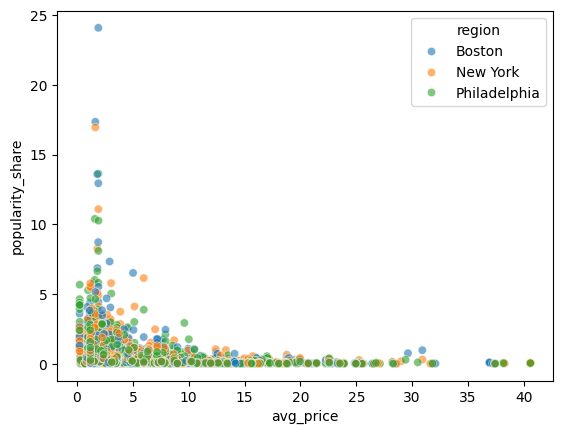

In [89]:
sns.scatterplot(
    data=item_state,
    x="avg_price",
    y="popularity_share",
    hue="region",
    alpha=0.6
)

In [90]:
price_pop_corr = (
    item_state
    .groupby("item")
    .apply(lambda x: x["avg_price"].corr(x["popularity_share"]))
    .rename("price_pop_corr")
    .reset_index()
)

In [91]:
price_pop_corr

,item,price_pop_corr
0,ACCESORIES_1_001,-0.90
1,ACCESORIES_1_002,0.61
2,ACCESORIES_1_003,1.00
3,ACCESORIES_1_004,0.29
4,ACCESORIES_1_005,-0.08
...,...,...
3044,SUPERMARKET_3_823,0.35
3045,SUPERMARKET_3_824,0.80
3046,SUPERMARKET_3_825,-0.94
3047,SUPERMARKET_3_826,0.86


In [92]:
item_support = (
    item_state
    .groupby("item")
    .agg(
        n_states=("region", "nunique"),
        price_std=("avg_price", "std"),
        pop_std=("popularity_share", "std")
    )
    .reset_index()
)

In [93]:
price_pop_corr = price_pop_corr.merge(
    item_support, on="item", how="left"
)

In [94]:
q_low = price_pop_corr["price_pop_corr"].quantile(0.25)
q_high = price_pop_corr["price_pop_corr"].quantile(0.75)

In [95]:
def price_segment(x):
    if pd.isna(x):
        return "insufficient_data"
    elif x >= q_high:
        return "premium"
    elif x <= q_low:
        return "price_sensitive"
    else:
        return "neutral"

price_pop_corr["price_segment"] = (
    price_pop_corr["price_pop_corr"].apply(price_segment)
)

In [96]:
item_popularity = (
    item_state
    .groupby("item")["total_sales"]
    .sum()
    .rename("total_sales")
)

price_pop_corr = price_pop_corr.merge(
    item_popularity, on="item"
)

In [97]:
sales_threshold = price_pop_corr["total_sales"].quantile(0.6)

best_items = price_pop_corr[
    (price_pop_corr["total_sales"] >= sales_threshold) &
    (price_pop_corr["price_segment"].isin(["premium", "price_sensitive"]))
]

In [98]:
best_items.sort_values("pop_std", ascending = False).head(10)

,item,price_pop_corr,n_states,price_std,pop_std,price_segment,total_sales
2450,SUPERMARKET_3_226,-0.96,3,0.00,6.43,price_sensitive,363082
2476,SUPERMARKET_3_252,-0.94,3,0.00,4.85,price_sensitive,565299
2314,SUPERMARKET_3_090,1.00,3,0.02,3.91,premium,1002529
2918,SUPERMARKET_3_694,-1.00,3,0.00,3.49,price_sensitive,390001
2542,SUPERMARKET_3_318,0.86,3,0.01,1.90,premium,260598
2659,SUPERMARKET_3_435,0.94,3,0.01,1.80,premium,99356
2426,SUPERMARKET_3_202,-0.90,3,0.07,1.80,price_sensitive,295689
1706,SUPERMARKET_1_096,0.94,3,1.31,1.36,premium,92357
2267,SUPERMARKET_3_042,0.67,3,0.01,1.31,premium,92924
2007,SUPERMARKET_2_181,-0.87,3,0.09,1.23,price_sensitive,138531


In [99]:
best_items.sort_values("price_pop_corr", ascending = False).head()

,item,price_pop_corr,n_states,price_std,pop_std,price_segment,total_sales
2314,SUPERMARKET_3_090,1.00,3,0.02,3.91,premium,1002529
2733,SUPERMARKET_3_509,1.00,3,0.02,0.10,premium,18706
918,HOME_&_GARDEN_1_361,1.00,3,0.00,0.11,premium,27028
415,ACCESORIES_1_424,1.00,3,0.08,0.04,premium,15307
2386,SUPERMARKET_3_162,1.00,3,0.08,0.08,premium,17941


## Clustering

## TS 3: Feature Engineering --> añadir columnas

- Comprobar la correlación de la venta de un item dentro de una categoría, así como la venta de una categoría dentro de una tienda o región
- Jugar con correlaciones con ventas entre region, shop, category e item, entre ellas a pares

Revision de las tiendas que más han crecido y las que menos

Ventas por año en vez de totales? Productos más longevos tendrán más ventas

Ventas de productos pero que tengan ventas en el último año

serie temporal por item y store: en prophet
o xgboost

Comparación: métricas --> desvío en %, para tener en cuenta variación de magnitud de ventas --> más explicativo



Clustering:
Modelo de clustering: segmentación --> modelo no supervisado --> le pasamos una k con grupos de parámetros --> búsqueda de grupos similares para comprimir los 8000 items en pocos grupos
Estratégia del codo --> kmeans --> monta centroides en el espacio, se mueven los centroides para acercarse a los puntos --> la entropía se reduce con la cantidad de grupos, hay que encontrar el sweet spot (por lo general 5-6 grupos, si muchos no es fácil explicar)


In [100]:
df_dsMarket = df_dsMarket.reset_index(drop=True)

In [101]:
df_dsMarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46027957 entries, 0 to 46027956
Data columns (total 18 columns):
 #   Column      Dtype         
---  ------      -----         
 0   id          category      
 1   item        object        
 2   category    category      
 3   department  category      
 4   store       category      
 5   store_code  object        
 6   region      category      
 7   day         object        
 8   sales       int64         
 9   date        datetime64[ns]
 10  start_date  datetime64[ns]
 11  yearweek    int64         
 12  event       object        
 13  is_Ramadan  bool          
 14  sell_price  float64       
 15  store_id    object        
 16  is_Event    bool          
 17  revenue     float64       
dtypes: bool(2), category(5), datetime64[ns](2), float64(2), int64(2), object(5)
memory usage: 4.1+ GB


In [102]:
df_dsMarket

,id,item,category,department,store,store_code,region,day,sales,date,start_date,yearweek,event,is_Ramadan,sell_price,store_id,is_Event,revenue
0,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_897,0,2013-07-13,2013-07-13,201328,NoEvent,True,12.74,BOS_1_ACCESORIES_1,False,0.00
1,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_898,0,2013-07-14,2013-07-13,201328,NoEvent,True,12.74,BOS_1_ACCESORIES_1,False,0.00
2,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_899,0,2013-07-15,2013-07-13,201328,NoEvent,True,12.74,BOS_1_ACCESORIES_1,False,0.00
3,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_900,1,2013-07-16,2013-07-13,201328,NoEvent,True,12.74,BOS_1_ACCESORIES_1,False,12.74
4,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_901,3,2013-07-17,2013-07-13,201328,NoEvent,True,12.74,BOS_1_ACCESORIES_1,False,38.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46027952,SUPERMARKET_3_827_PHI_3,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1909,0,2016-04-20,2014-03-01,201616,NoEvent,False,1.20,PHI_3_SUPERMARKET_3,False,0.00
46027953,SUPERMARKET_3_827_PHI_3,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1910,0,2016-04-21,2014-03-01,201616,NoEvent,False,1.20,PHI_3_SUPERMARKET_3,False,0.00
46027954,SUPERMARKET_3_827_PHI_3,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1911,0,2016-04-22,2014-03-01,201616,NoEvent,False,1.20,PHI_3_SUPERMARKET_3,False,0.00
46027955,SUPERMARKET_3_827_PHI_3,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1912,0,2016-04-23,2014-03-01,201617,NoEvent,False,1.20,PHI_3_SUPERMARKET_3,False,0.00


In [103]:
df_dsMarket.loc[df_dsMarket['start_date'] < '2011-02-01']

,id,item,category,department,store,store_code,region,day,sales,date,start_date,yearweek,event,is_Ramadan,sell_price,store_id,is_Event,revenue
36250,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_1,1,2011-01-29,2011-01-29,201105,NoEvent,False,5.77,BOS_1_ACCESORIES_1,False,5.77
36251,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_2,2,2011-01-30,2011-01-29,201105,NoEvent,False,5.77,BOS_1_ACCESORIES_1,False,11.54
36252,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_3,1,2011-01-31,2011-01-29,201105,NoEvent,False,5.77,BOS_1_ACCESORIES_1,False,5.77
36253,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_4,0,2011-02-01,2011-01-29,201105,NoEvent,False,5.77,BOS_1_ACCESORIES_1,False,0.00
36254,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_5,2,2011-02-02,2011-01-29,201105,NoEvent,False,5.77,BOS_1_ACCESORIES_1,False,11.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46010251,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1909,1,2016-04-20,2011-01-29,201616,NoEvent,False,4.78,PHI_3_SUPERMARKET_3,False,4.78
46010252,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1910,0,2016-04-21,2011-01-29,201616,NoEvent,False,4.78,PHI_3_SUPERMARKET_3,False,0.00
46010253,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1911,0,2016-04-22,2011-01-29,201616,NoEvent,False,4.78,PHI_3_SUPERMARKET_3,False,0.00
46010254,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1912,1,2016-04-23,2011-01-29,201617,NoEvent,False,4.78,PHI_3_SUPERMARKET_3,False,4.78


## 5. Predicción Prophet

### Funcion forecasting

In [104]:
def plot_item_forecast(item_name):
    
    df_item = (
        df_dsMarket[df_dsMarket['item'] == item_name]
        .groupby('date', as_index=False)
        .agg({
            'sales': 'sum',
            'sell_price': 'mean',   # or weighted if you want later
            'is_Event': 'max',
            'is_Ramadan': 'max',
            'event': 'first'
        })
    )
#------- SPLIT TRAIN TEST -------    
    df_item = df_item.sort_values('date')

    #for logistic growth, we need to set a floor and cap
    df_item['floor'] = 0
    df_item['cap'] = df_item['sales'].max()

    split_date = df_item['date'].quantile(0.8)  # 80% train

    train = df_item[df_item['date'] <= split_date]
    test  = df_item[df_item['date'] > split_date]

#------- TRAIN TEST for PROPHET ------- 
    train_prophet = train[['date','sales','sell_price','is_Ramadan']]\
        .rename(columns={'date':'ds','sales':'y'})
    test_prophet = test[['date','sales','sell_price','is_Ramadan']]\
        .rename(columns={'date':'ds','sales':'y'})

#------- HOLIDAYS ------- 
    holidays = (
        df_item[df_item['event'] != 'NoEvent'][['date', 'event']]
        .drop_duplicates()
        .rename(columns={'date': 'ds', 'event': 'holiday'})
    )
    holidays['lower_window'] = -2   # 2 days before
    holidays['upper_window'] = 1    # 1 days after

#------- MODEL -------
    model = Prophet(
        holidays=holidays,
        seasonality_mode='multiplicative',
        #growth='logistic',
        yearly_seasonality=True,
        daily_seasonality=False
    )

    model.add_seasonality(name='weekly', period=7, fourier_order=3, prior_scale=0.1) # the less the better, but it already has limitations

    model.add_regressor('sell_price')
    model.add_regressor('is_Ramadan')

    model.fit(train_prophet)

#------- FORECAST -------
    future = test_prophet[['ds', 'sell_price', 'is_Ramadan']]\
        .rename(columns = {'date':'ds'})
    forecast = model.predict(future)
    
#------- MAE ------- 
    print(len(test)+ len(train))
    forecast_test = forecast.set_index('ds').loc[test['date']]

    mae = mean_absolute_error(test['sales'], forecast_test['yhat'])

    print("MAE:", mae)

#------- PLOT ------- 
    fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=False)

    # --- Top plot: Train + Test + Forecast ---
    axes[0].plot(test['date'], test['sales'], label='Test')
    axes[0].plot(forecast['ds'], forecast['yhat'], label='Forecast')
    axes[0].plot(train['date'], train['sales'], label='Train', color='gray', alpha=0.5)
    axes[0].set_title('Prophet Forecast vs Actuals')
    axes[0].legend()

    # --- Bottom plot: Test + Forecast only ---
    axes[1].plot(test['date'], test['sales'], label='Test')
    axes[1].plot(forecast['ds'], forecast['yhat'], label='Forecast')
    axes[1].set_title('Test vs Forecast (Zoom)')
    axes[1].legend()
    axes[1].fill_between(
        forecast['ds'],
        forecast['yhat_lower'],
        forecast['yhat_upper'],
        alpha=0.2
    )

    plt.tight_layout()
    plt.show()


15:32:50 - cmdstanpy - INFO - Chain [1] start processing
15:32:50 - cmdstanpy - INFO - Chain [1] done processing


1122
MAE: 4.243084455036068


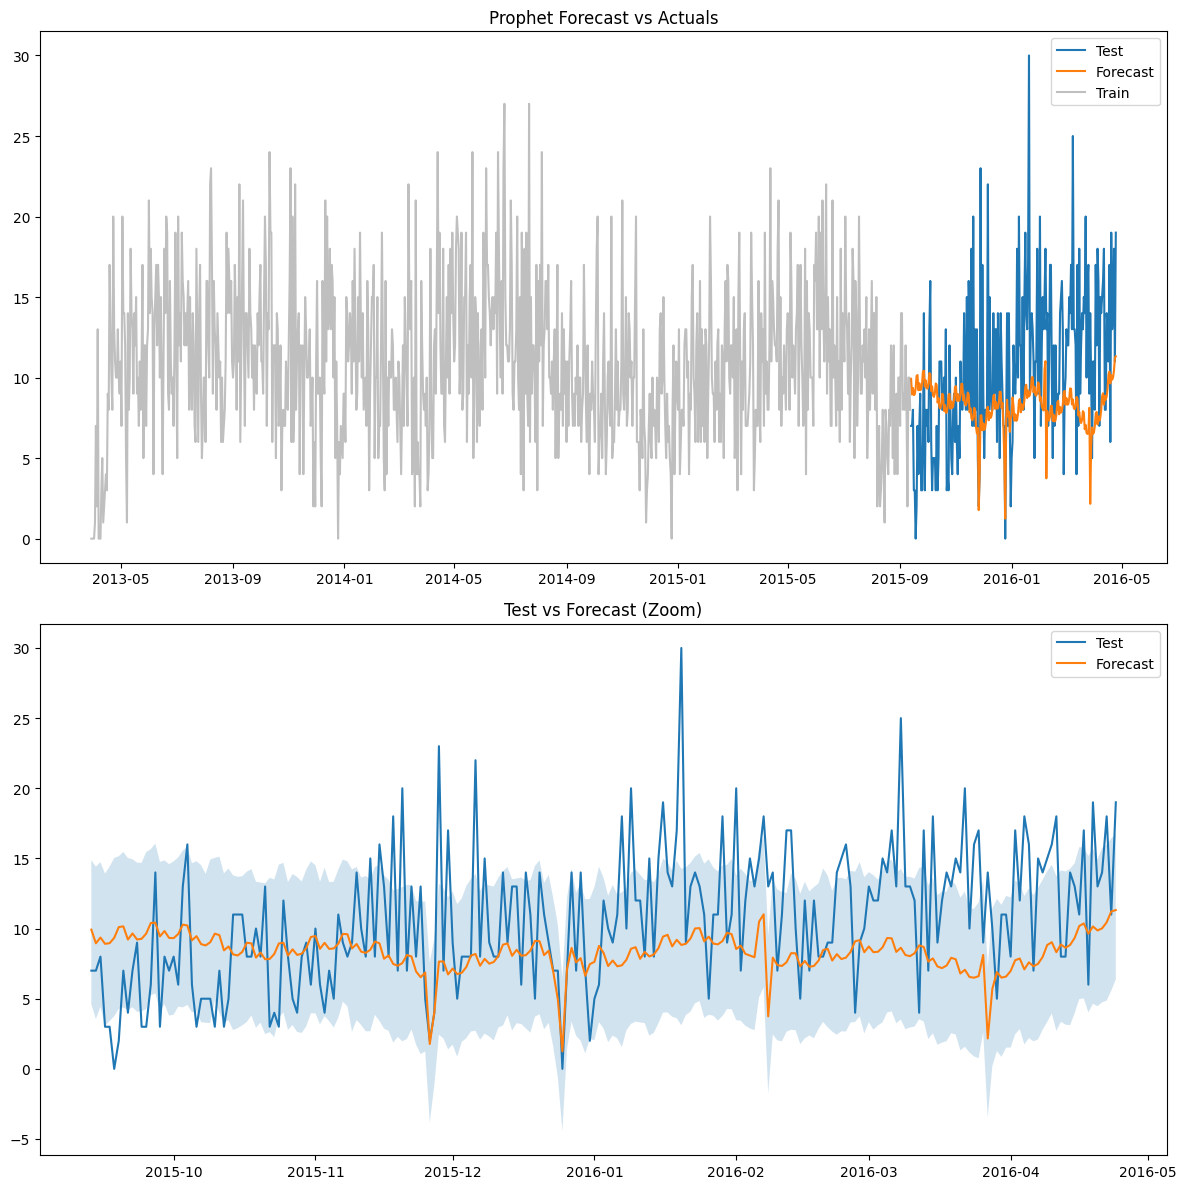

In [105]:
plot_item_forecast('SUPERMARKET_3_826')

## 6. Algoritmo XGBoost

In [106]:
# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
TARGET = "sales"
GROUP_COLS = ["store_code", "item"]
DATE_COL = "date"                        # raw date column (will be dropped after extraction)
 
# Columns to DROP entirely (pure identifiers / redundant)
DROP_COLS = ['id', 'day', 'store', "store_id", 'start_date', 'yearweek', 'revenue']         
 
# Categorical columns to ENCODE
CAT_COLS = ["item", "category", "department", "store_code", "region", "event"]
 
# Lag distances (in days)
LAG_DAYS = [1, 7, 14, 28]
 
# Rolling window sizes (in days)
ROLL_WINDOWS = [7, 14, 28]
 
TRAIN_RATIO = 0.8

In [107]:
# ─────────────────────────────────────────────
# 2. DROP REDUNDANT COLUMNS
# ─────────────────────────────────────────────
def drop_redundant(df: pd.DataFrame) -> pd.DataFrame:
    existing = [c for c in DROP_COLS if c in df.columns]
    df = df.drop(columns=existing)
    print(f"Dropped redundant columns: {existing}")
    return df

In [108]:
df_dsMarket_dropped_cols = drop_redundant(df_dsMarket)

Dropped redundant columns: ['id', 'day', 'store', 'store_id', 'start_date', 'yearweek', 'revenue']


In [109]:
# ─────────────────────────────────────────────
# 3. EXTRACT DATE FEATURES  →  DROP RAW DATE
# ─────────────────────────────────────────────
def add_date_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df[DATE_COL]
    df["day_of_week"]   = d.dt.dayofweek          # 0=Mon … 6=Sun
    df["day_of_month"]  = d.dt.day
    df["week_of_year"]  = d.dt.isocalendar().week.astype(int)
    df["month"]         = d.dt.month
    df["quarter"]       = d.dt.quarter
    df["is_weekend"]    = (d.dt.dayofweek >= 5).astype(int)
    df["year"]          = d.dt.year
    df = df.drop(columns=[DATE_COL])
    print("Added date features and dropped raw date column.")
    return df

In [110]:
# ─────────────────────────────────────────────
# 4. ENCODE CATEGORICALS
# ─────────────────────────────────────────────
def encode_categoricals(df: pd.DataFrame) -> tuple[pd.DataFrame, OrdinalEncoder]:
    existing_cats = [c for c in CAT_COLS if c in df.columns]
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    df[existing_cats] = enc.fit_transform(df[existing_cats]).astype(int)
    print(f"Encoded categoricals: {existing_cats}")
    return df, enc

In [111]:
# ─────────────────────────────────────────────
# 5. LAG FEATURES  (per store_code × item_id)
# ─────────────────────────────────────────────
def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    # NOTE: df must still be sorted by [date-equivalent cols] + GROUP_COLS at this point.
    # Since we dropped the date column we rely on the sort done at load time.
    grp = df.groupby(GROUP_COLS)[TARGET]
    for lag in LAG_DAYS:
        df[f"lag_{lag}"] = grp.shift(lag)
    print(f"Added lag features: {[f'lag_{l}' for l in LAG_DAYS]}")
    return df

In [112]:
# ─────────────────────────────────────────────
# 6. ROLLING FEATURES  (per store_code × item_id)
# ─────────────────────────────────────────────
def add_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    grp = df.groupby(GROUP_COLS)[TARGET]
    for w in ROLL_WINDOWS:
        # shift(1) prevents leakage: window ends the day BEFORE the current row
        rolled = grp.shift(1).groupby(df[GROUP_COLS[0]])   # re-group after shift
        # Simpler: use transform with shift inside
        shifted = grp.shift(1)
        df[f"roll_mean_{w}"] = (
            shifted.groupby([df[c] for c in GROUP_COLS])
                   .transform(lambda x: x.rolling(w, min_periods=1).mean())
        )
        df[f"roll_std_{w}"] = (
            shifted.groupby([df[c] for c in GROUP_COLS])
                   .transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
        )
    print(f"Added rolling mean/std features for windows: {ROLL_WINDOWS}")
    return df

In [113]:
# ─────────────────────────────────────────────
# 7. DROP NaN ROWS FROM LAG/ROLLING
# ─────────────────────────────────────────────
def drop_nan_rows(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    df = df.dropna().reset_index(drop=True)
    print(f"Dropped {before - len(df):,} NaN rows (from lag/rolling warmup). Remaining: {len(df):,}")
    return df

In [114]:
# ─────────────────────────────────────────────
# 8. TEMPORAL TRAIN / TEST SPLIT  (no shuffle)
# ─────────────────────────────────────────────
def temporal_split(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    split_idx = int(len(df) * TRAIN_RATIO)
    train, test = df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()
    print(f"Train: {len(train):,} rows | Test: {len(test):,} rows")
    return train, test

In [115]:
# ─────────────────────────────────────────────
# 9. FEATURE / TARGET SPLIT
# ─────────────────────────────────────────────
def split_X_y(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    X = df.drop(columns=[TARGET])
    y = df[TARGET]
    return X, y

In [116]:
# ─────────────────────────────────────────────
# EVALUATION HELPER
# ─────────────────────────────────────────────
def evaluate(y_true, y_pred, name: str):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    # Zero-sale accuracy: % of days where both actual and predicted are 0
    zero_acc = np.mean((y_true == 0) & (y_pred < 0.5)) / max(np.mean(y_true == 0), 1e-9)
    print(f"{name:12s} | MAE: {mae:.4f}  RMSE: {rmse:.4f}  Zero-accuracy: {zero_acc:.2%}")

In [117]:
# ─────────────────────────────────────────────
# 10a. TRAIN — XGBOOST
# ─────────────────────────────────────────────
def train_xgboost(X_train, y_train, X_test, y_test):
    print("\n── XGBoost ──")
    model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",       # fast histogram method
        early_stopping_rounds=30,
        eval_metric="mae",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=100,
    )
    preds = model.predict(X_test)
    preds = np.maximum(preds, 0)   # clip negatives — demand can't be < 0
    evaluate(y_test, preds, "XGBoost")
    return model, preds

In [118]:
# ─────────────────────────────────────────────
# 10b. TRAIN — LIGHTGBM
# ─────────────────────────────────────────────
def train_lightgbm(X_train, y_train, X_test, y_test):
    print("\n── LightGBM ──")
 
    # LightGBM can use native categoricals — re-cast them
    cat_features = [c for c in CAT_COLS if c in X_train.columns]
    X_train_lgb = X_train.copy()
    X_test_lgb  = X_test.copy()
    for col in cat_features:
        X_train_lgb[col] = X_train_lgb[col].astype("category")
        X_test_lgb[col]  = X_test_lgb[col].astype("category")
 
    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=30,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(
        X_train_lgb, y_train,
        eval_set=[(X_test_lgb, y_test)],
        categorical_feature=cat_features,
        callbacks=[lgb.log_evaluation(100)],
    )
    preds = model.predict(X_test_lgb)
    preds = np.maximum(preds, 0)
    evaluate(y_test, preds, "LightGBM")
    return model, preds

In [119]:
# ─────────────────────────────────────────────
# MAIN PIPELINE
# ─────────────────────────────────────────────
def run_pipeline(df: pd.DataFrame) -> dict:
    #df = load_data(data_path)
    df = drop_redundant(df)
    df = add_date_features(df)
    df, encoder = encode_categoricals(df)
    df = add_lag_features(df)
    df = add_rolling_features(df)
    df = drop_nan_rows(df)
 
    train_df, test_df = temporal_split(df)
    X_train, y_train = split_X_y(train_df)
    X_test,  y_test  = split_X_y(test_df)
 
    print(f"\nFeatures ({len(X_train.columns)}): {list(X_train.columns)}\n")
 
    xgb_model, xgb_preds = train_xgboost(X_train, y_train, X_test, y_test)
    lgb_model, lgb_preds = train_lightgbm(X_train, y_train, X_test, y_test)
 
    return {
        "xgb": xgb_model,
        "lgb": lgb_model,
        "X_test": X_test,
        "y_test": y_test,
        "xgb_preds": xgb_preds,
        "lgb_preds": lgb_preds,
    }
 
 
if __name__ == "__main__":
    # Replace with your actual file path
    results = run_pipeline(df_dsMarket)

Dropped redundant columns: ['id', 'day', 'store', 'store_id', 'start_date', 'yearweek', 'revenue']
Added date features and dropped raw date column.
Encoded categoricals: ['item', 'category', 'department', 'store_code', 'region', 'event']
Added lag features: ['lag_1', 'lag_7', 'lag_14', 'lag_28']
Added rolling mean/std features for windows: [7, 14, 28]
Dropped 853,720 NaN rows (from lag/rolling warmup). Remaining: 45,174,237
Train: 36,139,389 rows | Test: 9,034,848 rows

Features (26): ['item', 'category', 'department', 'store_code', 'region', 'event', 'is_Ramadan', 'sell_price', 'is_Event', 'day_of_week', 'day_of_month', 'week_of_year', 'month', 'quarter', 'is_weekend', 'year', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_28', 'roll_std_28']


── XGBoost ──
[0]	validation_0-mae:2.59912
[100]	validation_0-mae:1.54873
[101]	validation_0-mae:1.54876
XGBoost      | MAE: 1.5466  RMSE: 3.7375  Zero-accuracy: 52.98%

── LightGBM 